<a href="https://colab.research.google.com/github/ChoHyeonJun86/Perosnal_Project/blob/main/deeplearning_%ED%95%98%ED%92%88_%EA%B0%90%EC%A7%80_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B_%EB%A1%9C%EB%93%9C_%EB%B0%8F_%EC%A0%84%EC%B2%98%EB%A6%AC_%EC%BD%94%EB%93%9C%2C_%EB%AA%A8%EB%8D%B8_%ED%99%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


Yawn Dataset 다운로드 중...
Dataset URL: https://www.kaggle.com/datasets/davidvazquezcic/yawn-dataset
License(s): CC-BY-NC-SA-4.0
yawn-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Yawn Dataset 압축 해제 중...
replace no yawn/2760.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

--- 클래스별 이미지 개수 확인 중 ---
현재 /content/ 디렉토리 내용:
total 17432
drwxr-xr-x 2 root root    69632 Jun  7 19:45 'no yawn'
drwxr-xr-x 1 root root     4096 Jun  5 13:38  sample_data
drwxr-xr-x 2 root root    69632 Jun  7 19:45  yawn
-rw-r--r-- 1 root root 17705022 Jul  9  2021  yawn-dataset.zip
'yawn' 클래스 이미지 개수: 2528개
'no yawn' 클래스 이미지 개수: 2591개
경고: 'yawn'과 'no yawn' 클래스의 이미지 개수가 다릅니다. 데이터 불균형이 존재할 수 있습니다.

하품 데이터셋 로드 중 (tf.keras.utils.image_dataset_from_directory 사용)...
Found 5119 files belonging to 2 classes.
Using 4096 files for training.
Found 5119 files belonging to 2 classes.
Using 1023 files for validation.

--- 하품 데이터셋 로드 정보 ---
하품 훈련 데이터: 약 4096개 이미지
하품 검증 데이터: 약 1024개 이미지
하품

<ipython-input-12-f0d4ac946926>:118: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Class: {yawn_class_names[int(labels[i].numpy())]}")


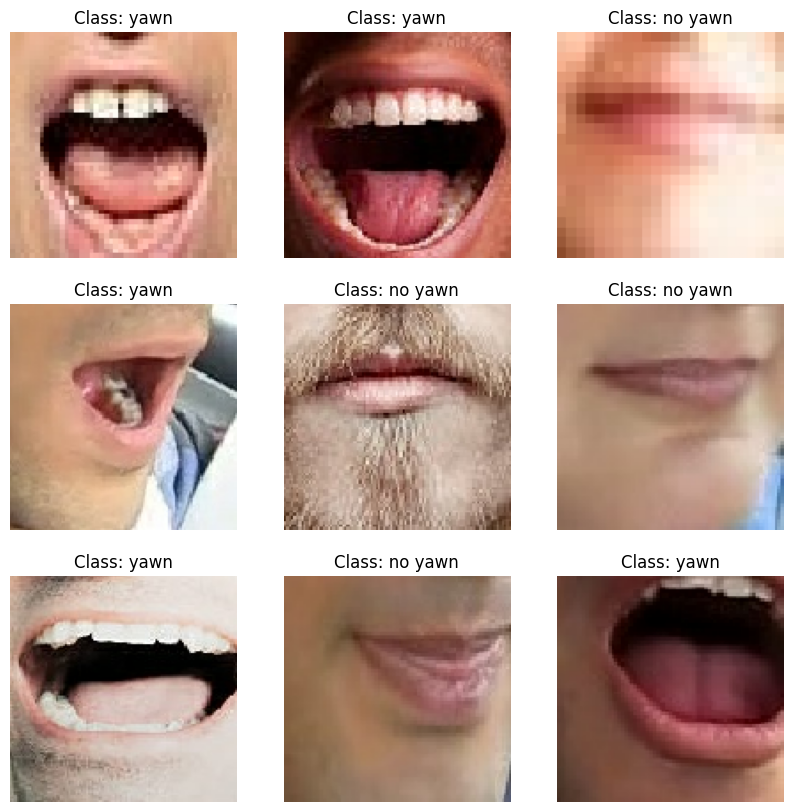

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 하품 데이터셋 다운로드 및 압축 해제 ---
# Yawn Dataset (davidvazquezcic) 다운로드 및 압축 해제
# Colab 환경에서 다음 명령어를 실행합니다.
print("Yawn Dataset 다운로드 중...")
!kaggle datasets download -d davidvazquezcic/yawn-dataset
print("Yawn Dataset 압축 해제 중...")
# -o 옵션을 제거하고 기본적인 unzip 명령을 사용합니다.
# 만약 'replace [파일이름]?'과 같은 프롬프트가 뜨면 'A'를 입력하고 Enter를 눌러주세요.
!unzip -qq yawn-dataset.zip

# --- 2. 하품 데이터셋 경로 설정 ---
# 'yawn-dataset.zip' 압축 해제 후 '/content/' 바로 아래에 'yawn'과 'no yawn' 폴더가 생성되었음을 확인했습니다.
yawn_base_dir = '/content/' # 이 경로는 'yawn'과 'no yawn' 폴더의 상위 디렉토리입니다.

# --- 3. 클래스별 이미지 개수 확인 (데이터 균형 문제 확인을 위함) ---
print("\n--- 클래스별 이미지 개수 확인 중 ---")
print("현재 /content/ 디렉토리 내용:")
!ls -l /content/ # 디렉토리 내용을 직접 확인

try:
    yawn_count = len(os.listdir(os.path.join(yawn_base_dir, 'yawn')))
    no_yawn_count = len(os.listdir(os.path.join(yawn_base_dir, 'no yawn')))

    print(f"'yawn' 클래스 이미지 개수: {yawn_count}개")
    print(f"'no yawn' 클래스 이미지 개수: {no_yawn_count}개")

    if yawn_count != no_yawn_count:
        print("경고: 'yawn'과 'no yawn' 클래스의 이미지 개수가 다릅니다. 데이터 불균형이 존재할 수 있습니다.")
    else:
        print("정보: 'yawn'과 'no yawn' 클래스의 이미지 개수가 동일합니다. 데이터 균형이 잘 맞습니다.")
except FileNotFoundError as e:
    print(f"경로 오류: {e}. 데이터셋 폴더를 찾을 수 없습니다. Kaggle API 설정 및 경로를 다시 확인해주세요.")
    raise # 오류를 다시 발생시켜 이후 코드가 실행되지 않도록 합니다.


# --- 4. 데이터셋 로드 (tf.keras.utils.image_dataset_from_directory 사용) ---
YAWN_IMG_WIDTH = 128
YAWN_IMG_HEIGHT = 128
YAWN_BATCH_SIZE = 32

print("\n하품 데이터셋 로드 중 (tf.keras.utils.image_dataset_from_directory 사용)...")

# 훈련 데이터셋 로드
yawn_train_ds_raw = tf.keras.utils.image_dataset_from_directory( # 원본 데이터셋 객체 저장
    yawn_base_dir,
    labels='inferred', # 폴더 이름으로 클래스 자동 추론
    label_mode='binary', # 이진 분류이므로 binary
    image_size=(YAWN_IMG_WIDTH, YAWN_IMG_HEIGHT),
    interpolation='nearest', # 이미지 크기 조정 시 보간 방법
    batch_size=YAWN_BATCH_SIZE,
    shuffle=True, # 훈련 데이터는 섞음
    seed=42, # 재현성을 위한 시드
    validation_split=0.2, # 훈련 데이터의 20%를 검증 데이터로 분리
    subset='training',
    # 명시적으로 클래스 이름 제공 (폴더 이름과 일치해야 함)
    class_names=['yawn', 'no yawn'] # 순서를 명확히 지정하여 인덱스 일치 보장
)

# 검증 데이터셋 로드
yawn_val_ds_raw = tf.keras.utils.image_dataset_from_directory( # 원본 데이터셋 객체 저장
    yawn_base_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(YAWN_IMG_WIDTH, YAWN_IMG_HEIGHT),
    interpolation='nearest',
    batch_size=YAWN_BATCH_SIZE,
    shuffle=False, # 검증 데이터는 섞지 않음 (성능 평가를 위해)
    seed=42,
    validation_split=0.2,
    subset='validation',
    # 명시적으로 클래스 이름 제공
    class_names=['yawn', 'no yawn']
)

# class_names는 원본 데이터셋 객체에서 접근해야 하므로, 여기서 미리 저장합니다.
yawn_class_names = yawn_train_ds_raw.class_names


# 데이터 전처리 함수 (정규화)
# image_dataset_from_directory는 픽셀 값을 0-255로 로드하므로 0-1로 정규화합니다.
def preprocess_yawn_data(image, label):
    # tf.cast를 먼저 적용하여 이미지 데이터 타입을 tf.float32로 변환 후 나누기 연산을 수행합니다.
    image = tf.cast(image, tf.float32) / 255.0 # 0-1 정규화
    return image, label

# 데이터셋에 전처리 적용 및 최적화
yawn_train_ds = yawn_train_ds_raw.map(preprocess_yawn_data, num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
yawn_val_ds = yawn_val_ds_raw.map(preprocess_yawn_data, num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# 데이터셋 로드 결과 확인
# tf.data.Dataset의 샘플 수는 cardinality를 통해 얻을 수 있습니다.
# 각 배치의 크기가 BATCH_SIZE이므로, 전체 이미지 수는 (batch_count * batch_size)로 추정합니다.
# 다만, 마지막 배치는 작을 수 있어 정확한 샘플 수와는 다를 수 있습니다.
train_samples_count = tf.data.experimental.cardinality(yawn_train_ds).numpy() * YAWN_BATCH_SIZE
val_samples_count = tf.data.experimental.cardinality(yawn_val_ds).numpy() * YAWN_BATCH_SIZE

print("\n--- 하품 데이터셋 로드 정보 ---")
print(f"하품 훈련 데이터: 약 {train_samples_count}개 이미지")
print(f"하품 검증 데이터: 약 {val_samples_count}개 이미지")
print(f"하품 클래스 이름: {yawn_class_names}") # 저장된 변수 사용


# --- (선택 사항: 첫 번째 배치 이미지 시각화) ---
# 이 부분은 주석 처리되어 있지만, 필요하다면 주석을 해제하여 데이터가 올바르게 로드되었는지 시각적으로 확인할 수 있습니다.
for images, labels in yawn_train_ds.take(1): # 훈련 데이터셋에서 첫 번째 배치 가져오기
    plt.figure(figsize=(10, 10))
    for i in range(min(9, YAWN_BATCH_SIZE)): # 최대 9개 이미지 시각화
        if i < images.shape[0]: # 배치 내 이미지 수가 batch_size보다 적을 경우 대비
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy()) # 정규화된 이미지는 0-1이므로 바로 imshow 가능
            # yawn_class_names 변수 사용
            plt.title(f"Class: {yawn_class_names[int(labels[i].numpy())]}")
            plt.axis('off')
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--- 모델 초기 요약 (헤드만 학습 가능) ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,289 (8.93 MB)

 Trainable params: 82,177 (321.00 KB)

...

 Total params: 2,340,289 (8.93 MB)

 Trainable params: 82,177 (321.00 KB)

 Non-trainable params: 2,258,112 (8.61 MB)


하품 감지 모델 미세 조정 학습 시작...
Epoch 45/64
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9772 - loss: 0.1022
Epoch 45: val_accuracy improved from -inf to 0.99022, saving model to best_yawn_model_finetuned.h5


128/128 ━━━━━━━━━━━━━━━━━━━━ 81s 569ms/step - accuracy: 0.9772 - loss: 0.1022 - val_accuracy: 0.9902 - val_loss: 0.0771
Epoch 46/64
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9791 - loss: 0.0974
Epoch 46: val_accuracy did not improve from 0.99022
128/128 ━━━━━━━━━━━━━━━━━━━━ 79s 548ms/step - accuracy: 0.9791 - loss: 0.0973 - val_accuracy: 0.9883 - val_loss: 0.0813
Epoch 47/64
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9821 - loss: 0.0972
Epoch 47: val_accuracy did not improve from 0.99022
128/128 ━━━━━━━━━━━━━━━━━━━━ 83s 558ms/step - accuracy: 0.9822 - loss: 0.0972 - val_accuracy: 0.9883 - val_loss: 0.0821
Epoch 48/64
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9785 - loss: 0.0927
Epoch 48: val_accuracy did not improve from 0.99022
128/128 ━━━━━━━━━━━━━━━━━━━━ 89s 616ms/step - accuracy: 0.9786 - loss: 0.0926 - val_accuracy: 0.9883 - val_loss: 0.0822
Epoch 49/64
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9825 - loss: 0.0896
Epoch 49

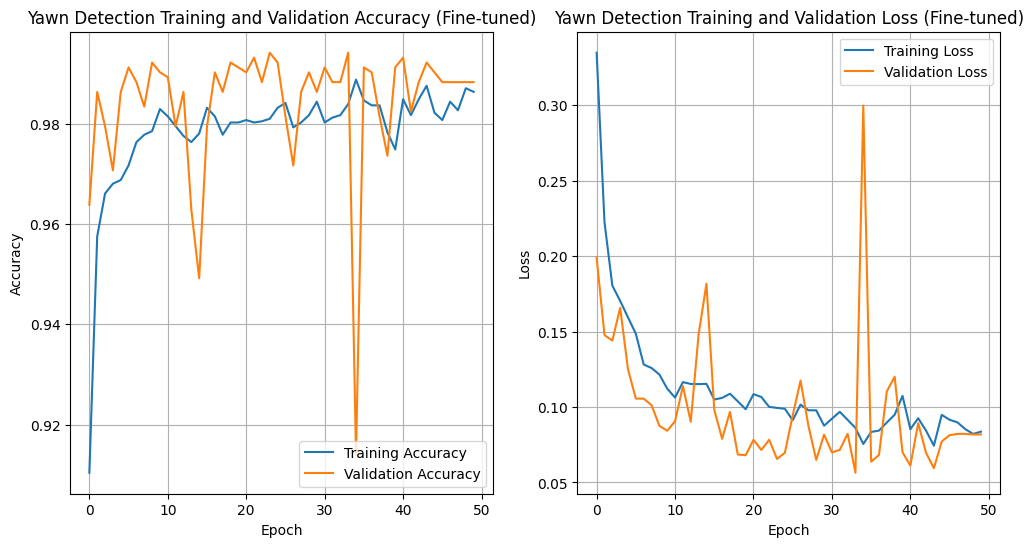


최종 학습 결과 시각화 완료.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os # 파일 존재 여부 확인을 위해 os 모듈 추가
from sklearn.utils import class_weight # class_weight 계산을 위해 import

# 이전에 정의된 IMG_WIDTH, IMG_HEIGHT, BATCH_SIZE (하품 데이터셋용)를 다시 정의합니다.
YAWN_IMG_WIDTH = 128
YAWN_IMG_HEIGHT = 128
YAWN_BATCH_SIZE = 32

# --- 1. 하품 감지 모델 구축 (전이 학습 적용) ---
# 사전 학습된 MobileNetV2 모델을 로드하여 전이 학습을 적용합니다.
# include_top=False: 분류 층(fully connected layers)은 제외하고 특징 추출 부분만 가져옵니다.
# weights='imagenet': ImageNet 데이터셋으로 사전 학습된 가중치를 사용합니다.
# input_shape: 모델에 입력될 이미지의 크기를 정의합니다.
yawn_base_model = applications.MobileNetV2(
    input_shape=(YAWN_IMG_WIDTH, YAWN_IMG_HEIGHT, 3),
    include_top=False,
    weights='imagenet'
)

# 베이스 모델의 층들을 동결(freeze)하여 학습되지 않도록 합니다.
yawn_base_model.trainable = False

# 새로운 분류 층(classification head)을 베이스 모델 위에 추가합니다.
def create_yawn_detection_model(base_model, input_shape):
    model = models.Sequential([
        base_model, # 사전 학습된 MobileNetV2 모델
        layers.GlobalAveragePooling2D(), # 특징 맵의 공간 차원을 줄입니다.
        layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # 뉴런 64개, L2 정규화
        layers.BatchNormalization(), # 학습 안정화를 위한 배치 정규화
        layers.Dropout(0.6), # 과적합 방지를 위한 드롭아웃
        layers.Dense(1, activation='sigmoid') # 이진 분류를 위한 출력 층
    ])
    return model

# 하품 감지 모델 생성
yawn_model = create_yawn_detection_model(yawn_base_model, (YAWN_IMG_WIDTH, YAWN_IMG_HEIGHT, 3))

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
print("--- 모델 초기 요약 (헤드만 학습 가능) ---")
yawn_model.summary()

# 모델 컴파일 (1단계: 헤드 학습)
yawn_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# --- 데이터셋 구성 확인 코드 ---
# 훈련 데이터셋에서 첫 번째 배치를 가져옵니다.
for images, labels in yawn_train_ds.take(1): # yawn_train_ds 사용
    print("\n--- 훈련 데이터셋 첫 번째 배치 정보 ---")
    print(f"이미지 배치 형태: {images.shape}")
    print(f"이미지 배치 데이터 타입: {images.dtype}")
    print(f"레이블 배치 형태: {labels.shape}")
    print(f"레이블 배치 데이터 타입: {labels.dtype}")
    print(f"이미지 픽셀 값 범위 (최소, 최대): ({tf.reduce_min(images).numpy():.4f}, {tf.reduce_max(images).numpy():.4f})")
    break # 첫 번째 배치만 확인하고 루프 종료

# 검증 데이터셋에서 첫 번째 배치를 가져옵니다.
for images, labels in yawn_val_ds.take(1): # yawn_val_ds 사용
    print("\n--- 검증 데이터셋 첫 번째 배치 정보 ---")
    print(f"이미지 배치 형태: {images.shape}")
    print(f"이미지 배치 데이터 타입: {images.dtype}")
    print(f"레이블 배치 형태: {labels.shape}")
    print(f"레이블 배치 데이터 타입: {labels.dtype}")
    print(f"이미지 픽셀 값 범위 (최소, 최대): ({tf.reduce_min(images).numpy():.4f}, {tf.reduce_max(images).numpy():.4f})")
    break # 첫 번째 배치만 확인하고 루프 종료
# --- 데이터셋 구성 확인 코드 종료 ---


# --- 2. 하품 감지 모델 학습 (1단계: 헤드 학습) ---
print("\n하품 감지 모델 학습 시작 (1단계: 헤드 학습)...")

# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
yawn_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
yawn_model_checkpoint = ModelCheckpoint(
    'best_yawn_model_head_only.h5', # 헤드만 학습된 모델 저장 파일 이름
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 데이터 불균형 해결을 위한 class_weight 계산
# 이 값들은 'yawn_detection_code_load_data' Canvas에서 확인했습니다.
# 'yawn' 클래스 이미지 개수: 2528개
# 'no yawn' 클래스 이미지 개수: 2591개

# 클래스 레이블의 실제 분포를 반영하여 가중치 계산
total_samples = 2528 + 2591 # 총 샘플 수
class_weights_dict = {
    0: total_samples / (2 * 2528), # 'yawn' (레이블 0)
    1: total_samples / (2 * 2591)  # 'no yawn' (레이블 1)
}
print(f"\n계산된 클래스 가중치: {class_weights_dict}")


history_head_only = yawn_model.fit(
    yawn_train_ds, # tf.data.Dataset 객체 사용 (yawn_train_generator -> yawn_train_ds로 변경)
    epochs=50, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도
    validation_data=yawn_val_ds, # tf.data.Dataset 객체 사용 (yawn_val_generator -> yawn_val_ds로 변경)
    callbacks=[yawn_early_stopping, yawn_model_checkpoint],
    class_weight=class_weights_dict # 클래스 가중치 적용
)

print("\n하품 감지 모델 1단계 학습 완료 (헤드 학습).")

# --- 3. 전이 학습 미세 조정 (Fine-tuning) ---
print("\n--- 전이 학습 미세 조정 시작 ---")

# 1단계에서 저장된 최적의 모델을 로드합니다.
# 이렇게 하면 미세 조정이 최적의 상태에서 시작됩니다.
if os.path.exists('best_yawn_model_head_only.h5'):
    yawn_model = models.load_model('best_yawn_model_head_only.h5')
    print("1단계 학습된 최적의 모델을 로드했습니다.")
else:
    print("경고: 'best_yawn_model_head_only.h5' 파일이 없습니다. 미세 조정은 현재 모델 상태에서 진행됩니다.")


# 베이스 모델의 모든 층을 다시 학습 가능하도록 설정합니다.
yawn_base_model.trainable = True

# 매우 낮은 학습률로 모델을 다시 컴파일합니다.
yawn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 매우 낮은 학습률 (0.00001)
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- 미세 조정 모델 요약 (전체 모델 학습 가능) ---")
yawn_model.summary() # 학습 가능 파라미터 수 변화 확인

# 미세 조정을 위한 콜백 설정
fine_tune_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # patience를 더 짧게 설정
fine_tune_model_checkpoint = ModelCheckpoint(
    'best_yawn_model_finetuned.h5', # 미세 조정된 모델 저장 파일 이름
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 미세 조정 학습을 시작합니다. (이전 학습의 이어서)
print("\n하품 감지 모델 미세 조정 학습 시작...")
fine_tune_epochs = 20 # 미세 조정을 위한 추가 에포크 수
# 이전 학습의 마지막 에포크부터 이어서 시작하도록 initial_epoch를 설정합니다.
initial_epoch_fine_tune = len(history_head_only.history['loss'])

history_fine_tune = yawn_model.fit(
    yawn_train_ds, # tf.data.Dataset 객체 사용
    epochs=initial_epoch_fine_tune + fine_tune_epochs, # 총 에포크는 이전 에포크 + 미세 조정 에포크
    initial_epoch=initial_epoch_fine_tune, # 이전 학습 이어서 시작
    validation_data=yawn_val_ds, # tf.data.Dataset 객체 사용
    callbacks=[fine_tune_early_stopping, fine_tune_model_checkpoint],
    class_weight=class_weights_dict # 클래스 가중치 적용 (미세 조정 단계에도 적용)
)

print("\n하품 감지 모델 미세 조정 완료.")

# --- 4. 최종 학습 결과 시각화 (두 단계 합치기) ---
# 두 단계의 학습 기록을 합칩니다.
history_combined_acc = history_head_only.history['accuracy'] + history_fine_tune.history['accuracy']
history_combined_val_acc = history_head_only.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
history_combined_loss = history_head_only.history['loss'] + history_fine_tune.history['loss']
history_combined_val_loss = history_head_only.history['val_loss'] + history_fine_tune.history['val_loss']

total_epochs_range = range(len(history_combined_acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(total_epochs_range, history_combined_acc, label='Training Accuracy')
plt.plot(total_epochs_range, history_combined_val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Yawn Detection Training and Validation Accuracy (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(total_epochs_range, history_combined_loss, label='Training Loss')
plt.plot(total_epochs_range, history_combined_val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Yawn Detection Training and Validation Loss (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

print("\n최종 학습 결과 시각화 완료.")


In [ ]:
# ---모델 저장---
yawn_model.save('/content/drive/MyDrive/best_yawn_model_finetuned.h5')
print("하품 감지 모델이 Google Drive에 저장되었습니다.")

하품 감지 모델이 Google Drive에 저장되었습니다.


In [28]:
import cv2
import dlib
import numpy as np
import imutils
from imutils import face_utils
from tensorflow.keras.models import load_model
import os
import time # 시간 측정을 위한 모듈
from google.colab.patches import cv2_imshow # Colab에서 이미지 표시를 위함 (주석 해제)

# --- 0. Dlib 얼굴 특징점 예측 모델 다운로드 ---
# 모델 파일 경로 설정
predictor_path = "shape_predictor_68_face_landmarks.dat"

# 파일이 없으면 다운로드 (Colab 환경에서)
if not os.path.exists(predictor_path):
    print("Dlib 얼굴 특징점 예측 모델 다운로드 중...")
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2
    print("Dlib 모델 다운로드 및 압축 해제 완료.")
else:
    print("Dlib 모델이 이미 존재합니다.")

# --- 1. 학습된 모델 로드 ---
# 모델 파일 경로 설정 (기본은 /content/, Google Drive 사용 시 변경)
# Google Drive에 모델을 저장했다면, 아래 경로를 Google Drive 경로로 수정하세요.
# 예: /content/drive/MyDrive/best_drowsiness_model_transfer.h5
EYE_MODEL_PATH = '/content/drive/MyDrive/best_drowsiness_model_transfer.h5' # 이 부분을 Google Drive 경로로 수정하세요!
YAWN_MODEL_PATH = '/content/drive/MyDrive/best_yawn_model_finetuned.h5'   # 이 부분을 Google Drive 경로로 수정하세요!

# Google Drive 마운트 확인 및 안내 (코드가 실행될 때 경로 오류를 미리 알려줍니다)
if not os.path.exists(EYE_MODEL_PATH) or not os.path.exists(YAWN_MODEL_PATH):
    print("\n경고: 모델 파일을 지정된 경로에서 찾을 수 없습니다.")
    print("EYE_MODEL_PATH와 YAWN_MODEL_PATH 변수에 Google Drive에 저장된")
    print("모델 파일의 정확한 경로를 입력했는지 확인하세요.")
    print("예: EYE_MODEL_PATH = '/content/drive/MyDrive/your_drowsiness_model.h5'")
    print("    YAWN_MODEL_PATH = '/content/drive/MyDrive/your_yawn_model.h5'")
    print("\n만약 Google Drive에 저장하지 않았다면, 이전 학습 코드를 다시 실행하여 모델 파일을 생성해야 합니다.")
    # 실제 프로그램 종료를 위해 exit()를 사용할 수 있지만, Colab에서 디버깅 용이성을 위해 주석 처리합니다.
    # exit() # 모델 로드 실패 시 프로그램 종료

print("\n학습된 눈 감지 모델 로드 중...")
try:
    eye_detection_model = load_model(EYE_MODEL_PATH)
    print("눈 감지 모델 로드 완료.")
except Exception as e:
    print(f"눈 감지 모델 로드 실패: {e}")
    print(f"'{EYE_MODEL_PATH}' 경로의 모델 파일이 올바른지 확인하거나, 이전 학습 코드를 다시 실행하세요.")
    exit() # 모델 로드 실패 시 프로그램 종료

print("\n학습된 하품 감지 모델 로드 중...")
try:
    yawn_detection_model = load_model(YAWN_MODEL_PATH)
    print("하품 감지 모델 로드 완료.")
except Exception as e:
    print(f"하품 감지 모델 로드 실패: {e}")
    print(f"'{YAWN_MODEL_PATH}' 경로의 모델 파일이 올바른지 확인하거나, 이전 학습 코드를 다시 실행하세요.")
    exit() # 모델 로드 실패 시 프로그램 종료

# --- 2. Dlib 얼굴 검출기 및 특징점 예측기 초기화 ---
print("\nDlib 검출기 및 예측기 초기화 중...")
detector = dlib.get_frontal_face_detector() # 얼굴 검출기
predictor = dlib.shape_predictor(predictor_path) # 특징점 예측기
print("Dlib 초기화 완료.")

# --- 3. 눈과 입 특징점 인덱스 정의 ---
# Dlib 68점 특징점 인덱스에서 눈과 입 부분 추출
(lStart, lEnd) = face_utils.FACIAL_LANDMARKS_68_IDXS["left_eye"]
(rStart, rEnd) = face_utils.FACIAL_LANDMARKS_68_IDXS["right_eye"]
(mStart, mEnd) = face_utils.FACIAL_LANDMARKS_68_IDXS["mouth"]

# --- 4. 졸음 감지 파라미터 설정 ---
EYE_CLOSED_THRESHOLD = 0.5 # 눈 감김 모델 예측 확률 임계값 (0.5 이상이면 감김)
YAWN_THRESHOLD = 0.5       # 하품 모델 예측 확률 임계값 (0.5 이상이면 하품)

EYE_CLOSED_FRAMES_CONSEC = 20 # 눈이 연속적으로 감겨야 졸음으로 판단하는 프레임 수 (약 0.6초 ~ 1초)
YAWN_COUNT_THRESHOLD = 3   # 일정 시간 내 하품 횟수
YAWN_INTERVAL_SECONDS = 60 # 하품 횟수를 카운트할 시간 (초)

# 상태 변수 초기화
eye_closed_counter = 0 # 눈 감김 연속 프레임 카운터
yawn_timestamps = []   # 하품 발생 시간 기록

DROWSY_STATUS = "정상"
ALERT_MESSAGE = ""

# --- 5. 비디오 처리 함수 정의 ---
def process_frame(frame, visualize=True):
    global eye_closed_counter, yawn_timestamps, DROWSY_STATUS, ALERT_MESSAGE

    # 프레임을 흑백으로 변환 (dlib는 흑백 이미지에서 더 잘 작동)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 얼굴 검출
    rects = detector(gray, 0) # 0은 이미지 오버샘플링 횟수

    # 현재 프레임의 졸음 상태 및 경고 메시지를 임시로 초기화
    frame_drowsy_flag = False
    frame_alert_message = ""
    current_eye_status_display = "눈_감지_안_됨" # 디스플레이용 초기값
    current_yawn_status_display = "입_감지_안_됨" # 디스플레이용 초기값
    eye_pred_display = float('nan') # 예측값 디스플레이용
    yawn_pred_display = float('nan') # 예측값 디스플레이용

    if not rects: # 얼굴이 감지되지 않으면 카운터 초기화
        eye_closed_counter = 0
        DROWSY_STATUS = "정상"
        ALERT_MESSAGE = "얼굴 감지 안 됨"
        # 이전 프레임에서 설정된 경고 메시지가 있을 수 있으므로 현재 프레임의 상태 초기화
        return frame # 얼굴이 없으면 더 이상 처리하지 않고 프레임 반환

    # 얼굴이 감지된 경우에만 졸음 상태 및 경고 메시지를 "정상"으로 초기화
    # 얼굴은 있지만 아직 졸음으로 판단되지 않은 상태를 반영
    DROWSY_STATUS = "정상"
    ALERT_MESSAGE = ""


    for rect in rects:
        try:
            # 얼굴 특징점 추출
            shape = predictor(gray, rect)
            shape = face_utils.shape_to_np(shape)

            # --- 눈 영역 추출 및 분류 ---
            left_eye = shape[lStart:lEnd]
            right_eye = shape[rStart:rEnd]

            # (x, y, w, h) 경계 박스 정보 (dlib.rectangle 객체에서 직접 추출)
            # face_utils.rect_to_boundingbox 대신 rect 객체 속성 사용
            x_rect_face = rect.left()
            y_rect_face = rect.top()
            w_rect_face = rect.width()
            h_rect_face = rect.height()


            x_le, y_le, w_le, h_le = cv2.boundingRect(left_eye) # left_eye_img_raw 추출을 위한 x,y,w,h
            x_re, y_re, w_re, h_re = cv2.boundingRect(right_eye) # right_eye_img_raw 추출을 위한 x,y,w,h

            # 눈 이미지 유효성 검사 및 처리
            if h_le > 0 and w_le > 0 and h_re > 0 and w_re > 0:
                left_eye_img_raw = gray[y_le:y_le + h_le, x_le:x_le + w_le]
                right_eye_img_raw = gray[y_re:y_re + h_re, x_re:x_re + w_re]

                if left_eye_img_raw.shape[0] > 0 and left_eye_img_raw.shape[1] > 0 and \
                   right_eye_img_raw.shape[0] > 0 and right_eye_img_raw.shape[1] > 0:
                    left_eye_img_resized = cv2.resize(left_eye_img_raw, (128, 128))
                    right_eye_img_resized = cv2.resize(right_eye_img_raw, (128, 128))

                    combined_eye_img = np.concatenate((left_eye_img_resized, right_eye_img_resized), axis=1)
                    combined_eye_img = cv2.resize(combined_eye_img, (128, 128))
                    combined_eye_img = np.stack([combined_eye_img, combined_eye_img, combined_eye_img], axis=-1)
                    combined_eye_img = np.expand_dims(combined_eye_img, axis=0) / 255.0

                    eye_prediction = eye_detection_model.predict(combined_eye_img, verbose=0)[0][0]
                    eye_pred_display = eye_prediction # 디스플레이용 업데이트

                    if eye_prediction < EYE_CLOSED_THRESHOLD: # 예측값이 0.5보다 작으면 Closed_Eyes (0)
                        current_eye_status_display = "눈_감음"
                        eye_closed_counter += 1
                        if eye_closed_counter >= EYE_CLOSED_FRAMES_CONSEC:
                            frame_drowsy_flag = True
                            frame_alert_message = "눈 감김! 주의하세요!"
                    else:
                        current_eye_status_display = "눈_뜸"
                        eye_closed_counter = 0 # 눈을 뜨면 카운터 초기화
                else:
                    current_eye_status_display = "눈_영역_오류"
                    eye_closed_counter = 0
            else:
                current_eye_status_display = "눈_영역_오류"
                eye_closed_counter = 0


            # --- 입 영역 추출 및 분류 (하품 감지) ---
            mouth = shape[mStart:mEnd]
            (x_m, y_m, w_m, h_m) = cv2.boundingRect(mouth)

            # 입 이미지 유효성 검사 및 처리
            if h_m > 0 and w_m > 0:
                mouth_img_raw = gray[y_m:y_m + h_m, x_m:x_m + w_m]
                if mouth_img_raw.shape[0] > 0 and mouth_img_raw.shape[1] > 0:
                    mouth_img_resized = cv2.resize(mouth_img_raw, (128, 128))
                    mouth_img = np.stack([mouth_img_resized, mouth_img_resized, mouth_img_resized], axis=-1)
                    mouth_img = np.expand_dims(mouth_img, axis=0) / 255.0

                    yawn_prediction = yawn_detection_model.predict(mouth_img, verbose=0)[0][0]
                    yawn_pred_display = yawn_prediction # 디스플레이용 업데이트

                    if yawn_prediction < YAWN_THRESHOLD: # 예측값이 0.5보다 작으면 'yawn' (0)
                        current_yawn_status_display = "하품_감지"
                        current_time = time.time()
                        # YAWN_INTERVAL_SECONDS 이내의 하품만 유지
                        yawn_timestamps = [ts for ts in yawn_timestamps if current_time - ts < YAWN_INTERVAL_SECONDS]
                        # 최근 하품이 아니라면 추가 (1초 이내 중복 하품 방지)
                        if not yawn_timestamps or (current_time - yawn_timestamps[-1] > 1):
                             yawn_timestamps.append(current_time)

                        if len(yawn_timestamps) >= YAWN_COUNT_THRESHOLD:
                            frame_drowsy_flag = True
                            if not frame_alert_message: # 눈 감김 경고가 없으면 하품 경고 설정
                                frame_alert_message = "잦은 하품! 졸음운전 위험!"
                            elif "눈 감김!" in frame_alert_message: # 눈 감김 경고가 이미 있다면 합치기
                                frame_alert_message += " (잦은 하품!)"
                    else:
                        current_yawn_status_display = "하품_아님"
                else:
                    current_yawn_status_display = "입_영역_오류"
            else:
                current_yawn_status_display = "입_영역_오류"

            # 최종 졸음 상태 업데이트 (가장 심각한 상태로 설정)
            if frame_drowsy_flag:
                DROWSY_STATUS = "졸음_감지"
                ALERT_MESSAGE = frame_alert_message
            # else: # 이 else 블록은 삭제. 얼굴이 감지됐지만 졸음이 아니면 DROWSY_STATUS는 "정상"이 됨
            #     DROWSY_STATUS = "정상"
            #     ALERT_MESSAGE = "" # 정상 상태에서는 경고 메시지 없음


            # 시각화 (얼굴 특징점, 눈/입 영역 표시)
            if visualize:
                # 얼굴 경계 박스
                # (x, y, w, h) = face_utils.rect_to_boundingbox(rect) # 이 줄 대신 아래 직접 추출 사용
                x = rect.left()
                y = rect.top()
                w = rect.width()
                h = rect.height()
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

                # 눈 특징점
                for (px, py) in left_eye:
                    cv2.circle(frame, (px, py), 1, (0, 0, 255), -1)
                for (px, py) in right_eye:
                    cv2.circle(frame, (px, py), 1, (0, 0, 255), -1)
                # 입 특징점
                for (px, py) in mouth:
                    cv2.circle(frame, (px, py), 1, (255, 0, 0), -1)

                # 눈/하품 상태 텍스트
                cv2.putText(frame, f"Eye: {current_eye_status_display} ({eye_pred_display:.2f})", (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                cv2.putText(frame, f"Yawn: {current_yawn_status_display} ({yawn_pred_display:.2f})", (10, 60),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                cv2.putText(frame, f"Drowsy: {DROWSY_STATUS}", (10, 90),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, ALERT_MESSAGE, (10, 120),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        except Exception as e:
            # 특정 얼굴 영역 처리 중 오류 발생 시 경고 출력 및 해당 프레임 처리 계속
            print(f"Warning: Error processing a face region: {e}. Skipping this face.")
            # 오류가 발생한 경우 졸음 상태를 다시 "정상"으로 설정하지 않도록 주의
            # 이 프레임의 다른 얼굴 또는 이전 프레임의 상태를 유지할 수 있음
            # 만약 현재 프레임에서 얼굴이 하나만 감지되었는데 오류가 났다면
            # 최종 상태를 "정상"으로 초기화하고 "처리 오류" 메시지를 띄웁니다.
            if len(rects) == 1:
                DROWSY_STATUS = "정상"
                ALERT_MESSAGE = "처리 오류 (얼굴 인식)"
            continue # 다음 rect로 넘어감

    return frame

# --- 6. 비디오 파일 처리 예시 ---
# Colab에 비디오 파일 업로드 후 사용
# 예: files.upload()를 통해 'input_video.mp4' 업로드
# 또는 Google Drive 마운트 후 경로 지정: /content/drive/MyDrive/input_video.mp4

# 비디오 파일 경로 설정 (사용자가 직접 업로드하거나 Google Drive에서 가져와야 함)
video_paths = [ # 여러 비디오 파일을 리스트로 정의
    '/content/drive/MyDrive/normal.mp4', # 평범한 운전 영상
    '/content/drive/MyDrive/sleepy.mp4'  # 졸린 운전 영상
]

# 출력 비디오의 목표 FPS 설정 (예: 30 FPS로 설정)
# 이렇게 설정하면 원본 비디오의 FPS가 낮더라도 출력 비디오는 30 FPS로 저장되어 더 부드럽게 보일 수 있습니다.
# (원본 비디오 FPS가 더 낮다면, 프레임이 중복 저장될 수 있습니다.)
TARGET_OUTPUT_FPS = 30


# 비디오 파일 처리 루프
for video_path in video_paths:
    if not os.path.exists(video_path):
        print(f"\n경고: 비디오 파일 '{video_path}'를 찾을 수 없습니다.")
        print("테스트를 위해 비디오 파일을 업로드하거나, 아래 정적 이미지 처리 예시를 활성화하세요.")
        print("예: Colab 좌측 파일 아이콘 -> 파일 업로드 -> input_video.mp4 (또는 다른 비디오 파일) 업로드")
        print("   Google Drive에 있다면: video_path = '/content/drive/MyDrive/your_video.mp4'")
        continue # 다음 비디오로 넘어감 (파일 없으면 처리하지 않음)
    else:
        cap = cv2.VideoCapture(video_path)

        # 비디오 속성 가져오기 (FPS, 프레임 너비/높이)
        input_fps = int(cap.get(cv2.CAP_PROP_FPS)) # 원본 비디오의 FPS
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"\n비디오 파일 '{video_path}' 처리 시작...")
        print(f"입력 비디오 FPS: {input_fps}, Width: {width}, Height: {height}, Total Frames: {total_frames}")

        # 비디오 출력 저장을 위한 VideoWriter 객체 생성 (선택 사항)
        # 각 비디오마다 다른 출력 파일명 사용
        output_video_filename = os.path.basename(video_path).replace('.mp4', '_processed.mp4')
        output_video_path = os.path.join('/content/', output_video_filename) # /content/ 에 저장
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') # 코덱 설정
        # VideoWriter에 TARGET_OUTPUT_FPS 적용
        out = cv2.VideoWriter(output_video_path, fourcc, TARGET_OUTPUT_FPS, (width, height))
        print(f"처리된 비디오는 '{output_video_path}'로 {TARGET_OUTPUT_FPS} FPS로 저장됩니다.")

        frame_count = 0
        start_time = time.time()
        try:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                processed_frame = process_frame(frame.copy(), visualize=True)

                # 프레임 이미지로 저장 (테스트용)
                # 1초에 1프레임만 저장 (FPS를 고려하여 조절)
                # if frame_count % input_fps == 0: # 원본 FPS 기준으로 저장
                #     cv2.imwrite(f'/content/{os.path.basename(video_path).replace(".mp4", "")}_frame_{frame_count:05d}.jpg', processed_frame)

                # 비디오 파일로 저장 (활성화 시)
                out.write(processed_frame) # 비디오 파일로 저장 활성화

                frame_count += 1
                if frame_count % (input_fps * 5) == 0: # 5초마다 진행 상황 출력 (원본 FPS 기준)
                    elapsed_time = time.time() - start_time
                    print(f"처리 중... {frame_count}/{total_frames} 프레임 ({elapsed_time:.2f}초 경과)")

        except Exception as e:
            print(f"비디오 '{video_path}' 처리 중 오류 발생: {e}")
        finally:
            cap.release()
            if 'out' in locals() and out.isOpened():
                out.release()
            print(f"\n비디오 '{video_path}' 처리 완료.")
            print(f"처리된 비디오는 '{output_video_path}'에 저장되었습니다. 다운로드하여 확인하세요.")
            print(f"최종 졸음 상태: {DROWSY_STATUS}")
            print(f"최종 경고 메시지: {ALERT_MESSAGE}")



Dlib 모델이 이미 존재합니다.

학습된 눈 감지 모델 로드 중...


눈 감지 모델 로드 완료.

학습된 하품 감지 모델 로드 중...


하품 감지 모델 로드 완료.

Dlib 검출기 및 예측기 초기화 중...
Dlib 초기화 완료.

비디오 파일 '/content/drive/MyDrive/normal.mp4' 처리 시작...
입력 비디오 FPS: 25, Width: 1280, Height: 720, Total Frames: 141
처리된 비디오는 '/content/normal_processed.mp4'로 30 FPS로 저장됩니다.
처리 중... 125/141 프레임 (55.17초 경과)

비디오 '/content/drive/MyDrive/normal.mp4' 처리 완료.
처리된 비디오는 '/content/normal_processed.mp4'에 저장되었습니다. 다운로드하여 확인하세요.
최종 졸음 상태: 졸음_감지
최종 경고 메시지: 눈 감김! 주의하세요!

비디오 파일 '/content/drive/MyDrive/sleepy.mp4' 처리 시작...
입력 비디오 FPS: 25, Width: 1280, Height: 720, Total Frames: 141
처리된 비디오는 '/content/sleepy_processed.mp4'로 30 FPS로 저장됩니다.
처리 중... 125/141 프레임 (49.81초 경과)

비디오 '/content/drive/MyDrive/sleepy.mp4' 처리 완료.
처리된 비디오는 '/content/sleepy_processed.mp4'에 저장되었습니다. 다운로드하여 확인하세요.
최종 졸음 상태: 정상
최종 경고 메시지: 
